<a href="https://colab.research.google.com/github/VictorPontual/LTSM_Attention_FRtoPT_Tradution/blob/main/LTSM_Variations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Participantes:
- Enzo Emir Viana Ferraz - 231011293
- Marcelo Makoto Araki Takechi - 231026465
- Victor Pontual Guedes Arruda Nóbrega - 211029601

### **Modelo de Tradução com LSTM Simples**

Este modelo de tradução utiliza **LSTM** (Long Short-Term Memory) para converter texto de francês para português, aproveitando sua capacidade de lidar com sequências e capturar dependências de longo prazo nas frases.  

As LSTMs são redes neurais recorrentes (RNNs) projetadas para resolver o problema de gradientes explosivos e desaparecendo, que limitam as RNNs tradicionais. Elas são especialmente eficazes para tarefas como tradução, onde o contexto da entrada pode se estender por várias palavras ou até mesmo frases inteiras.

Neste modelo, o encoder LSTM processa a sequência de entrada (em francês) e gera uma representação que é passada para o decoder LSTM, que cria a tradução. A abordagem simples de LSTM garante que o modelo aprenda relações essenciais dentro da sequência, embora sem o aprimoramento do mecanismo de atenção.

## Configuração do ambiente e controle de aleatoriedade

Para garantir que os experimentos sejam reprodutíveis, é necessário definir uma semente para os geradores de números aleatórios. Isso evita variações indesejadas nos resultados a cada execução do código.

O primeiro passo é importar as bibliotecas necessárias. O TensorFlow será utilizado para a construção e treinamento do modelo, enquanto o `tensorflow_datasets` fornecerá o conjunto de dados. Além disso, o `matplotlib.pyplot` será usado para visualização dos dados, e o `numpy` auxiliará em operações matemáticas.

Em seguida, definimos a variável `SEED` com o valor 42 e aplicamos essa semente nos geradores de números aleatórios do TensorFlow, Python (`random`) e NumPy. Isso garante que todas as operações aleatórias retornem os mesmos valores em execuções repetidas, o que é essencial para comparar os resultados e avaliar o desempenho do modelo de forma consistente.


In [ ]:
# Importação das bibliotecas necessárias para o experimento
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import random
import numpy as np

# Definição da semente para garantir a reprodutibilidade dos experimentos
SEED = 42
tf.random.set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)


## Carregamento do conjunto de dados

Para treinar e avaliar o modelo de tradução, utilizamos o conjunto de dados `ted_hrlr_translate/fr_to_pt`, disponibilizado pelo `tensorflow_datasets`. Esse dataset contém sentenças traduzidas do francês para o português, extraídas de palestras TED, sendo uma excelente fonte para experimentos de tradução automática.

O comando `tfds.load()` é utilizado para carregar o dataset. Definimos o argumento `as_supervised=True` para que os exemplos sejam carregados no formato `(entrada, saída)`, onde a entrada é uma sentença em francês e a saída é a sua tradução correspondente em português. Além disso, o parâmetro `with_info=True` permite acessar metadados do conjunto de dados, incluindo o número de exemplos disponíveis para treinamento e validação.

Após o carregamento, os dados são divididos em duas partes: `train_data`, que contém os exemplos usados para treinar o modelo, e `test_data`, que será utilizado para avaliar seu desempenho. O conjunto de treinamento é essencial para ajustar os pesos do modelo, enquanto a validação permite verificar sua capacidade de generalização para novas traduções.


In [ ]:
data, metadata = tfds.load("ted_hrlr_translate/fr_to_pt", as_supervised=True, with_info=True)
train_data, test_data = data['train'], data['validation']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/43873 [00:00<?, ? examples/s]

...

Generating validation examples...:   0%|          | 0/1131 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/ted_hrlr_translate/fr_to_pt/incomplete.HBRPOI_1.0.0/ted_hrlr_translate-val…

Generating test examples...:   0%|          | 0/1494 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/ted_hrlr_translate/fr_to_pt/incomplete.HBRPOI_1.0.0/ted_hrlr_translate-tes…

Dataset ted_hrlr_translate downloaded and prepared to /root/tensorflow_datasets/ted_hrlr_translate/fr_to_pt/1.0.0. Subsequent calls will reuse this data.


## Visualização de exemplos do conjunto de treinamento

Para entender melhor a estrutura dos dados e verificar se o carregamento foi feito corretamente, podemos visualizar algumas amostras do conjunto de treinamento. Isso ajuda a garantir que as frases estejam formatadas corretamente e que o modelo receba os dados esperados.

O código percorre os primeiros cinco exemplos do `train_data`, extraindo as frases em francês (`fr`) e suas respectivas traduções em português (`pt`). Como os dados carregados pelo `tensorflow_datasets` são armazenados em formato `tf.Tensor`, é necessário converter os valores para strings legíveis. Isso é feito utilizando `.numpy().decode("utf-8")`, que transforma os tensores em strings UTF-8.

Cada par de frases é impresso no console, permitindo uma inspeção visual das sentenças e suas traduções. Essa etapa é útil para verificar a qualidade do dataset e identificar possíveis problemas antes de seguir para o pré-processamento e treinamento do modelo.


In [ ]:
for fr, pt in train_data.take(5):
    print("Francês:", fr.numpy().decode("utf-8"))
    print("Português:", pt.numpy().decode("utf-8"))
    print()

Francês: mais cela trahit aussi la panique , la terreur , que la grossophobie peut évoquer .
Português: mas também faz notar o pânico , o terror literal , que o medo da gordura evoca .

Francês: mais le vrai problème est le manque d'autres infrastructures .
Português: mas o verdadeiro problema é a falta de outras infraestruturas .

Francês: quand ils sont endommagés , par exemple par la fumée de cigarette , ils ne fonctionnent pas correctement , et ne peuvent pas expulser le mucus .
Português: quando são danificados , digamos , pelo fumo de cigarro , por exemplo , não funcionam adequadamente , e não conseguem limpar o muco .

Francês: beaucoup l'ont fait par le monde numérique .
Português: e a maioria conseguiu , no mundo digital .

Francês: eh bien si .
Português: há , sim .



## Tokenização das sentenças

Para que o modelo de tradução compreenda os textos de entrada e saída, é necessário converter as sentenças de texto em sequências numéricas. Esse processo é realizado por um tokenizador, que transforma as palavras ou caracteres em representações numéricas utilizáveis pelo modelo.

Definimos dois tokenizadores utilizando a camada `TextVectorization` do TensorFlow Keras: um para as sentenças em francês (`french_tokenizer`) e outro para as sentenças em português (`portuguese_tokenizer`). Essa camada converte textos em sequências de inteiros, onde cada número representa um token específico no vocabulário.

Para limitar o tamanho do vocabulário e garantir que o modelo consiga lidar com os dados de forma eficiente, utilizamos a variável `MAX_TOKENS`, que define um limite de 5000 tokens distintos para cada idioma. Além disso, para evitar que sequências muito longas afetem o desempenho do modelo, estabelecemos um comprimento máximo de 40 tokens através da variável `MAX_SEQUENCE_LENGTH`. Sentenças mais curtas são preenchidas até esse tamanho, enquanto sentenças mais longas são truncadas.

Com essa configuração, garantimos que os textos sejam processados de maneira padronizada, facilitando o treinamento do modelo de tradução.


In [ ]:
MAX_TOKENS = 5000
MAX_SEQUENCE_LENGTH = 40


french_tokenizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS, output_mode="int", output_sequence_length=MAX_SEQUENCE_LENGTH
)
portuguese_tokenizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS, output_mode="int", output_sequence_length=MAX_SEQUENCE_LENGTH
)

## Preparação dos textos para tokenização

Após definir os tokenizadores, é necessário fornecer exemplos de texto para que eles aprendam o vocabulário presente no conjunto de dados. Esse processo é chamado de *adaptação*, onde a camada `TextVectorization` analisa os textos e constrói um vocabulário eficiente para a conversão de palavras em números.

Primeiro, criamos duas listas vazias: `french_texts_train` e `portuguese_texts_train`. Em seguida, percorremos os dados de treinamento (`train_data`), extraindo as sentenças em francês (`fr`) e português (`pt`). Como os dados estão no formato `tf.Tensor`, utilizamos `tfds.as_numpy()` para convertê-los em arrays do NumPy, permitindo manipulação mais fácil. Depois, aplicamos `.decode("utf-8")` para transformar os tensores em strings legíveis e armazenamos as sentenças nas respectivas listas.

Com as listas de texto preparadas, chamamos o método `.adapt()` para os tokenizadores `french_tokenizer` e `portuguese_tokenizer`. Esse método analisa as frases, aprende a distribuição das palavras e constrói um vocabulário com base nos tokens mais frequentes, respeitando o limite de `MAX_TOKENS`. Dessa forma, garantimos que o modelo terá uma representação numérica eficiente das sentenças antes de iniciar o treinamento.


In [ ]:
french_texts_train, portuguese_texts_train = [], []
for fr, pt in tfds.as_numpy(train_data):
    french_texts_train.append(fr.decode("utf-8"))
    portuguese_texts_train.append(pt.decode("utf-8"))

french_tokenizer.adapt(french_texts_train)
portuguese_tokenizer.adapt(portuguese_texts_train)

## Preparação do conjunto de dados para treinamento

Após a tokenização das sentenças, é necessário preparar o conjunto de dados para que ele possa ser utilizado no treinamento do modelo. Para isso, criamos a função `prepare_dataset()`, que realiza a tokenização, embaralhamento, divisão em lotes (*batching*) e pré-processamento eficiente dos dados.

A função recebe um `dataset` como entrada e aplica a função `tokenize_map()` a cada exemplo do conjunto de dados. Dentro dessa função, os textos em francês (`fr`) e português (`pt`) são convertidos em sequências numéricas pelos tokenizadores `french_tokenizer` e `portuguese_tokenizer`.

No retorno, utilizamos a abordagem *teacher forcing*, onde os pares de entrada para o modelo são formados da seguinte maneira:
- `(fr, pt[:-1])`: A entrada do modelo contém a sentença original em francês (`fr`) e a tradução em português deslocada para a esquerda (removendo o último token).
- `pt[1:]`: A saída esperada do modelo é a mesma sentença em português, mas deslocada para a direita (removendo o primeiro token). Esse deslocamento permite que o modelo aprenda a prever o próximo token corretamente.

Após a tokenização, são aplicadas as seguintes otimizações ao `dataset`:
- `.shuffle(20000)`: Embaralha os exemplos para evitar que o modelo aprenda padrões indesejados na ordem dos dados.
- `.padded_batch(64)`: Agrupa os dados em lotes de 64 exemplos, preenchendo sequências menores para garantir que todos os exemplos do lote tenham o mesmo comprimento.
- `.prefetch(tf.data.AUTOTUNE)`: Melhora a eficiência do processamento ao pré-carregar lotes na memória enquanto o modelo está treinando, reduzindo gargalos.

Por fim, criamos os conjuntos de treinamento e teste chamando `prepare_dataset()` para `train_data` e `test_data`, garantindo que os dados estejam prontos para serem usados no treinamento do modelo.


In [ ]:
def prepare_dataset(dataset):
    def tokenize_map(fr, pt):
        fr = french_tokenizer(fr)
        pt = portuguese_tokenizer(pt)
        return (fr, pt[:-1]), pt[1:]

    return dataset.map(tokenize_map).shuffle(20000).padded_batch(64).prefetch(tf.data.AUTOTUNE)

train_dataset = prepare_dataset(train_data)
test_dataset = prepare_dataset(test_data)

## Construção do modelo de tradução

O modelo segue a arquitetura Encoder-Decoder com redes LSTM (*Long Short-Term Memory*), permitindo traduzir frases do francês para o português.

### Hiperparâmetros
- `EMBEDDING_DIM = 256`: Dimensão dos vetores de *embedding*.
- `UNITS = 512`: Unidades nas LSTMs para capturar dependências longas.
- `VOCAB_SIZE_FRENCH` e `VOCAB_SIZE_PORTUGUESE`: Tamanhos dos vocabulários de cada idioma.

### Estrutura do Modelo

- **Encoder**: Processa a entrada em francês e gera um estado interno (`state_h`, `state_c`) para representar o significado da frase.
- **Decoder**: Recebe esse estado interno e gera a tradução palavra por palavra. Inclui uma camada LSTM e uma camada densa com ativação `softmax`.

### Compilação

O modelo usa o otimizador **Adam** (`learning_rate=0.0005`), a função de perda **sparse_categorical_crossentropy** e mede a **acurácia**. A estrutura final é exibida com `model.summary()`, permitindo analisar os parâmetros treináveis.

Esse modelo aprende a traduzir utilizando memórias de longo prazo das LSTMs para lidar com dependências linguísticas complexas.


In [ ]:
EMBEDDING_DIM = 256
UNITS = 512
VOCAB_SIZE_FRENCH = french_tokenizer.vocabulary_size()
VOCAB_SIZE_PORTUGUESE = portuguese_tokenizer.vocabulary_size()

encoder_inputs = tf.keras.Input(shape=(None,), dtype='int64')
encoder_embedding = tf.keras.layers.Embedding(VOCAB_SIZE_FRENCH, EMBEDDING_DIM, mask_zero=True)(encoder_inputs)
encoder_outputs, state_h, state_c = tf.keras.layers.LSTM(UNITS, return_state=True, dropout=0.2, recurrent_dropout=0.2)(encoder_embedding)
encoder_states = [state_h, state_c]

decoder_inputs = tf.keras.Input(shape=(None,), dtype='int64')
decoder_embedding = tf.keras.layers.Embedding(VOCAB_SIZE_PORTUGUESE, EMBEDDING_DIM, mask_zero=True)(decoder_inputs)
decoder_lstm = tf.keras.layers.LSTM(UNITS, return_sequences=True, return_state=True, dropout=0.2, recurrent_dropout=0.2)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)
decoder_dense = tf.keras.layers.Dense(VOCAB_SIZE_PORTUGUESE, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

model = tf.keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, None)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, None)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, None, 256)      │      1,280,000 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ not_equal (NotEqual)      │ (None, None)           │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_1 (Embedding)   │ (None, None, 256)      │      1,280,000 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ [(None, 512), (None,   │      1,574,912 │ embedding[0][0],       │
│                           │ 512), (None, 512)]     │                │ not_equal[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ [(None, None, 512),    │      1,574,912 │ embedding_1[0][0],     │
│                           │ (None, 512), (None,    │                │ lstm[0][1], lstm[0][2] │
│                           │ 512)]                  │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, None, 5000)     │      2,565,000 │ lstm_1[0][0]           │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 8,274,824 (31.57 MB)

 Trainable params: 8,274,824 (31.57 MB)

 Non-trainable params: 0 (0.00 B)

# Treinamento

## Callbacks para treinamento do modelo

Para melhorar a eficiência do treinamento e evitar overfitting, utilizamos três callbacks do Keras:

- **ModelCheckpoint** (`checkpoint_cb`): Salva automaticamente o melhor modelo durante o treinamento com base na métrica de validação, garantindo que o modelo final seja o mais eficiente.
- **ReduceLROnPlateau** (`reduce_lr_cb`): Reduz a taxa de aprendizado em 50% (`factor=0.5`) caso a perda de validação não melhore por 3 épocas consecutivas, ajudando na convergência do modelo.
- **EarlyStopping** (`early_stopping_cb`): Interrompe o treinamento se a perda de validação não melhorar por 10 épocas, restaurando os melhores pesos encontrados.

Esses callbacks garantem um treinamento mais eficiente, evitando overfitting e acelerando a convergência.


In [ ]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True)
reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

## Treinamento do modelo

O modelo é treinado por até **50 épocas** usando `train_dataset`, com `test_dataset` para validação. Três callbacks são aplicados para otimização:
- **Checkpoint**: Salva o melhor modelo automaticamente.
- **ReduceLROnPlateau**: Reduz a taxa de aprendizado se a perda de validação não melhorar.
- **EarlyStopping**: Para o treinamento se não houver progresso por 10 épocas.

Essas estratégias garantem um treinamento eficiente e evitam overfitting.


In [ ]:
EPOCHS = 35
history = model.fit(train_dataset, epochs=EPOCHS, validation_data=test_dataset, callbacks=[checkpoint_cb, reduce_lr_cb, early_stopping_cb])

Epoch 1/35
686/686 ━━━━━━━━━━━━━━━━━━━━ 209s 286ms/step - accuracy: 0.5830 - loss: 5.9783 - val_accuracy: 0.7160 - val_loss: 5.0538 - learning_rate: 5.0000e-04
Epoch 2/35
686/686 ━━━━━━━━━━━━━━━━━━━━ 203s 292ms/step - accuracy: 0.7043 - loss: 5.0256 - val_accuracy: 0.7220 - val_loss: 4.7561 - learning_rate: 5.0000e-04
Epoch 3/35
686/686 ━━━━━━━━━━━━━━━━━━━━ 202s 289ms/step - accuracy: 0.7107 - loss: 4.7349 - val_accuracy: 0.7278 - val_loss: 4.5925 - learning_rate: 5.0000e-04
Epoch 4/35
686/686 ━━━━━━━━━━━━━━━━━━━━ 198s 283ms/step - accuracy: 0.7149 - loss: 4.5572 - val_accuracy: 0.7303 - val_loss: 4.4863 - learning_rate: 5.0000e-04
Epoch 5/35
686/686 ━━━━━━━━━━━━━━━━━━━━ 197s 283ms/step - accuracy: 0.7204 - loss: 4.4026 - val_accuracy: 0.7346 - val_loss: 4.3909 - learning_rate: 5.0000e-04
Epoch 6/35
686/686 ━━━━━━━━━━━━━━━━━━━━ 200s 287ms/step - accuracy: 0.7239 - loss: 4.2687 - val_accuracy: 0.7371 - val_loss: 4.2958 - learning_rate: 5.0000e-04
Epoch 7/35
686/686 ━━━━━━━━━━━━━━━━━━━━ 

## Visualização do desempenho do treinamento

Para analisar o desempenho do modelo, criamos a função `plot_history()`, que plota a evolução da **perda (loss)** ao longo das épocas.

### Funcionamento:
- Plota a perda do conjunto de **treinamento** (`history.history['loss']`).
- Plota a perda do conjunto de **validação** (`history.history['val_loss']`).
- Adiciona rótulos aos eixos (`Épocas` e `Loss`) e uma legenda para melhor interpretação.

Essa visualização ajuda a identificar **overfitting** (quando a perda de validação começa a aumentar enquanto a perda de treinamento continua diminuindo), permitindo ajustes no treinamento se necessário.


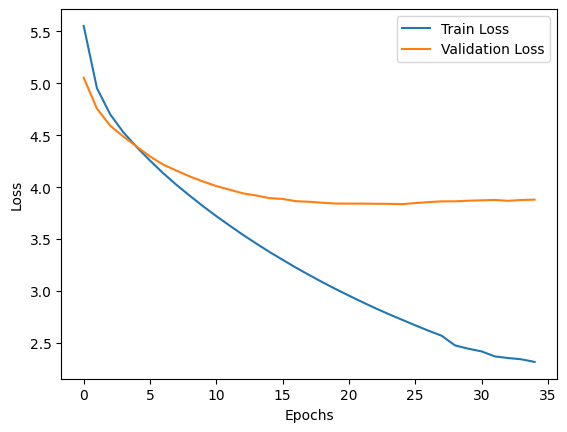

In [ ]:
def plot_history(history):
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_history(history)

## Justificativas das Escolhas no Modelo LSTM

### Por que escolhemos um LSTM unidirecional?
O uso de um LSTM unidirecional foi escolhido por ser mais simples, visto ser a primeira vez que os integrantes do grupo tem contato com o modelo das LSTM, decidimos abordar primeiramente o mais simples, para aprimorarmos nossa base.

### Por que usamos 512 unidades na camada LSTM?
O número de 512 unidades foi escolhido para proporcionar um balanço entre a capacidade do modelo de capturar padrões complexos e o custo computacional.

### Justificativa para o tamanho do embedding (256 dimensões)
O tamanho do embedding de 256 dimensões foi definido para capturar uma representação semântica rica das palavras, mantendo um custo computacional razoável. Esse tamanho permite que palavras com significados semelhantes sejam representadas de maneira próxima no espaço vetorial.

### Por que limitamos o vocabulário a 5000 palavras?
A escolha de limitar o vocabulário a 5000 palavras visa reduzir a complexidade do modelo e o tempo de treinamento, ao mesmo tempo em que cobre a grande maioria das palavras mais frequentes no dataset. Isso é importante para garantir que o modelo seja eficiente em termos computacionais.


### **Modelo de Tradução com LSTM e Atenção**

O modelo de tradução que criamos combina a potência das redes LSTM com um mecanismo de **atenção**, visando traduzir textos de francês para português de forma mais precisa e eficiente.

As LSTMs (Long Short-Term Memory) são perfeitas para lidar com sequências de dados, como frases, pois conseguem capturar as dependências de longo alcance, essenciais para entender o contexto e gerar traduções mais coerentes.

O truque do **mecanismo de atenção** é permitir que o modelo "preste atenção" nas partes mais importantes da frase original enquanto gera a tradução. Ao invés de depender exclusivamente da última palavra processada, ele pode focar em diferentes partes da sequência de entrada, melhorando a qualidade da tradução.

Essa combinação torna o modelo mais inteligente e flexível, capaz de lidar com as complexidades das línguas de forma mais natural e precisa!

### **Carregamento do Dataset e Configuração dos Tokenizers para Tradução**

Este código utiliza TensorFlow e TensorFlow Datasets para carregar e processar um conjunto de dados de tradução do francês para o português.  

1. **Importação e Carregamento dos Dados**  
   - O dataset `"ted_hrlr_translate/fr_to_pt"` é carregado e dividido em treino, validação e teste.  
   - As frases são organizadas como pares `(francês, português)`.  

2. **Definição dos Tokenizers**  
   - Dois tokenizers `TextVectorization` são criados para transformar texto em sequências numéricas.  
   - Os textos são convertidos para minúsculas, sem pontuação, e truncados/padronizados para 40 tokens.  

3. **Treinamento dos Tokenizers**  
   - O conjunto de treinamento é separado em frases em francês e português.  
   - Os tokenizers são ajustados (`adapt()`) para aprender o vocabulário e mapear as palavras para números.  

Este processamento prepara os dados para serem usados em modelos de tradução automática.

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

# Carregar o dataset de tradução (francês -> português)
data_set = "ted_hrlr_translate/fr_to_pt"
train_data, val_data = tfds.load(data_set, split=["train", "validation"], as_supervised=True)

# Definir os tokenizers para francês e português
tokenizer_en = tf.keras.layers.TextVectorization(
    standardize="lower_and_strip_punctuation", output_mode="int", output_sequence_length=40
)
tokenizer_pt = tf.keras.layers.TextVectorization(
    standardize="lower_and_strip_punctuation", output_mode="int", output_sequence_length=40
)

# Adaptar os tokenizers com o conjunto de dados
train_data_en = train_data.map(lambda en, pt: en).batch(32)
train_data_pt = train_data.map(lambda en, pt: pt).batch(32)

tokenizer_en.adapt(train_data_en)
tokenizer_pt.adapt(train_data_pt)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/43873 [00:00<?, ? examples/s]

...

Generating validation examples...:   0%|          | 0/1131 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/ted_hrlr_translate/fr_to_pt/incomplete.LZ2A1X_1.0.0/ted_hrlr_translate-val…

Generating test examples...:   0%|          | 0/1494 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/ted_hrlr_translate/fr_to_pt/incomplete.LZ2A1X_1.0.0/ted_hrlr_translate-tes…

Dataset ted_hrlr_translate downloaded and prepared to /root/tensorflow_datasets/ted_hrlr_translate/fr_to_pt/1.0.0. Subsequent calls will reuse this data.


### **Preparação e Tokenização dos Dados para Treinamento do Modelo de Tradução**

Este código prepara os dados para treinamento de um modelo de tradução, convertendo frases em francês e português para tensores numéricos.  

1. **Função `prepare_data(data)`**  
   - Recebe um conjunto de dados contendo pares `(francês, português)`.  
   - Converte cada frase em tokens numéricos usando `tokenizer_en` (para francês) e `tokenizer_pt` (para português).  
   - Os tokens são armazenados em `input_seq` (entrada) e `target_seq` (saída esperada).  

2. **Conversão para Tensores**  
   - `input_seq` e `target_seq` são transformados em tensores `input_tensor` e `target_tensor`.  
   - `decoder_input_tensor` é criado deslocando `target_tensor` para a direita, inserindo um token inicial (`0`). Isso é essencial para modelos de tradução seqüencial, onde a previsão de cada palavra depende das anteriores.  

Este processamento é fundamental para treinar um modelo de tradução baseado em aprendizado profundo.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Preparar os dados corretamente
def prepare_data(data):
    input_seq = []
    target_seq = []
    for en, pt in tfds.as_numpy(data):
        input_seq.append(tokenizer_en([en])[0].numpy())
        target_seq.append(tokenizer_pt([pt])[0].numpy())

    input_tensor = tf.convert_to_tensor(input_seq, dtype=tf.int32)
    target_tensor = tf.convert_to_tensor(target_seq, dtype=tf.int32)

    decoder_input_tensor = tf.concat([tf.zeros_like(target_tensor[:, :1]), target_tensor[:, :-1]], axis=1)
    return input_tensor, decoder_input_tensor, target_tensor

### **Construção do Modelo de Tradução com LSTM e Mecanismo de Atenção**  

Este código define um modelo de tradução baseado em redes neurais recorrentes (RNN) com mecanismo de atenção.  

1. **Camada de Atenção**  
   - A classe `Attention` calcula pesos de atenção entre a saída do decodificador e a saída do codificador, permitindo que o modelo foque em partes relevantes da sequência de entrada.  

2. **Definição do Modelo**  
   - Um codificador (`encoder`) com uma camada `Embedding` seguida de uma `LSTM` para processar frases em francês.  
   - Um decodificador (`decoder`) também com `Embedding` e `LSTM`, inicializado com os estados finais do codificador.  
   - O mecanismo de atenção é aplicado à saída do decodificador, ajustando a importância de cada palavra da entrada.  
   - A saída passa por uma camada `Dense` com ativação `softmax`, que gera a previsão da próxima palavra em português.  

3. **Construção e Compilação**  
   - O modelo é criado usando `tf.keras.Model`, recebe frases em francês e português como entrada e é treinado para minimizar a perda `sparse_categorical_crossentropy` com o otimizador `adam`.  
   - A função `model.summary()` exibe a arquitetura do modelo.  

Este modelo usa aprendizado profundo para traduzir frases do francês para o português de forma eficiente.

In [ ]:
# Definir a camada de Atenção
class Attention(tf.keras.layers.Layer):
    def __init__(self):
        super(Attention, self).__init__()
        self.softmax = tf.keras.layers.Softmax(axis=-1)

    def call(self, query, value):
        attention_scores = tf.matmul(query, value, transpose_b=True)
        attention_weights = self.softmax(attention_scores)
        context_vector = tf.matmul(attention_weights, value)
        return context_vector

# Definir o modelo
def build_model(vocab_size_en, vocab_size_pt, embedding_dim=128, lstm_units=128):
    # Entradas
    encoder_input = tf.keras.layers.Input(shape=(None,))
    decoder_input = tf.keras.layers.Input(shape=(None,))

    # Embedding
    encoder_embedding = tf.keras.layers.Embedding(vocab_size_en, embedding_dim)(encoder_input)
    decoder_embedding = tf.keras.layers.Embedding(vocab_size_pt, embedding_dim)(decoder_input)

    # LSTM para o codificador (encoder)
    encoder_lstm = tf.keras.layers.LSTM(lstm_units, return_sequences=True, return_state=True)
    encoder_output, state_h, state_c = encoder_lstm(encoder_embedding)

    # LSTM para o decodificador (decoder)
    decoder_lstm = tf.keras.layers.LSTM(lstm_units, return_sequences=True, return_state=False)
    decoder_output = decoder_lstm(decoder_embedding, initial_state=[state_h, state_c])

    # Aplicar atenção
    attention_layer = Attention()
    attention = attention_layer(decoder_output, encoder_output)

    # Concatenar atenção e saída do decodificador
    context_and_decoder = tf.keras.layers.Concatenate(axis=-1)([decoder_output, attention])

    # Camada final
    output = tf.keras.layers.Dense(vocab_size_pt, activation='softmax')(context_and_decoder)

    model = tf.keras.Model(inputs=[encoder_input, decoder_input], outputs=output)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Tamanho do vocabulário
vocab_size_en = len(tokenizer_en.get_vocabulary())
vocab_size_pt = len(tokenizer_pt.get_vocabulary())

# Construir o modelo
model = build_model(vocab_size_en, vocab_size_pt)

# Resumo do modelo
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, None)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, None)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, None, 128)      │      4,715,264 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_1 (Embedding)   │ (None, None, 128)      │      4,786,560 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ [(None, None, 128),    │        131,584 │ embedding[0][0]        │
│                           │ (None, 128), (None,    │                │                        │
│                           │ 128)]                  │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ (None, None, 128)      │        131,584 │ embedding_1[0][0],     │
│                           │                        │                │ lstm[0][1], lstm[0][2] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention (Attention)     │ (None, None, 128)      │              0 │ lstm_1[0][0],          │
│                           │                        │                │ lstm[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, None, 256)      │              0 │ lstm_1[0][0],          │
│                           │                        │                │ attention[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, None, 37395)    │      9,610,515 │ concatenate[0][0]      │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 19,375,507 (73.91 MB)

 Trainable params: 19,375,507 (73.91 MB)

 Non-trainable params: 0 (0.00 B)

### **Preparação e Loteamento dos Dados para Treinamento e Validação**  

Este código organiza os dados de tradução em lotes para o treinamento do modelo.  

1. **Preparação dos Dados**  
   - `prepare_data()` é usada para converter frases em tensores numéricos para treinamento e validação.  

2. **Criação de Lotes para Treinamento**  
   - Os dados são transformados em um `tf.data.Dataset`, organizados em pares `((entrada, entrada_decodificador), saída)`.  
   - `batch(32)` agrupa os dados em lotes de 32 amostras.  
   - `shuffle(buffer_size=1000)` embaralha os dados para melhorar o aprendizado do modelo.  

3. **Criação de Lotes para Validação**  
   - O mesmo processo é aplicado aos dados de validação, mas sem embaralhamento, pois a ordem dos dados não influencia na avaliação do modelo.  

Esse processamento otimiza o treinamento e a validação do modelo de tradução.

In [ ]:
# Preparar dados de treinamento
train_input, decoder_input, train_target = prepare_data(train_data)

# Criar lotes para os dados de treinamento
train_dataset = tf.data.Dataset.from_tensor_slices(((train_input, decoder_input), train_target))
train_dataset = train_dataset.batch(32).shuffle(buffer_size=1000)

# Preparar dados de validação
val_input, decoder_input, val_target = prepare_data(val_data)

# Criar lotes para os dados de validação
val_dataset = tf.data.Dataset.from_tensor_slices(((val_input, decoder_input), val_target))
val_dataset = val_dataset.batch(32)  # Não é necessário embaralhar os dados de validação

### **Configuração do Otimizador e Estratégia de Ajuste da Taxa de Aprendizado**  

Este código define o otimizador e um mecanismo para ajustar dinamicamente a taxa de aprendizado durante o treinamento.  

1. **Otimizador**  
   - Utiliza `Adam` com uma taxa de aprendizado inicial de `0.001`, combinando as vantagens de `Momentum` e `RMSprop` para um treinamento eficiente.  

2. **Callback para Redução da Taxa de Aprendizado**  
   - `ReduceLROnPlateau` monitora a perda na validação (`val_loss`).  
   - Se a perda não melhorar por 3 épocas (`patience=3`), a taxa de aprendizado é reduzida pela metade (`factor=0.5`).  
   - A taxa mínima permitida é `1e-6` para evitar valores extremamente pequenos.  
   - `verbose=1` exibe mensagens indicando quando a taxa de aprendizado é ajustada.  

Essa estratégia ajuda o modelo a convergir de forma estável e eficiente.

In [ ]:
# Definir o otimizador e a taxa de aprendizado
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Callbacks
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',  # Monitorar a perda no conjunto de validação
    factor=0.5,          # Reduzir a taxa de aprendizado pela metade
    patience=3,          # Esperar 3 épocas sem melhoria antes de reduzir a taxa de aprendizado
    min_lr=1e-6,         # Limite inferior para a taxa de aprendizado
    verbose=1            # Mostrar mensagens quando a taxa de aprendizado for reduzida
)

### **Treinamento do Modelo com Validação e Ajuste da Taxa de Aprendizado**  

Este código executa o treinamento do modelo de tradução utilizando os dados preparados.  

1. **Execução do Treinamento (`model.fit`)**  
   - `train_dataset` é usado como conjunto de treinamento.  
   - O treinamento ocorre por `35` épocas.  
   - `val_dataset` é utilizado para avaliar o desempenho do modelo em dados não vistos.  

2. **Uso de Callbacks**  
   - `reduce_lr` ajusta automaticamente a taxa de aprendizado se a perda de validação (`val_loss`) não melhorar após 3 épocas.  

3. **Configuração de Saída**  
   - `verbose=1` exibe o progresso do treinamento em tempo real.  

Esse processo ajusta os pesos do modelo para otimizar a tradução entre francês e português.

In [ ]:
# Treinar o modelo
model.fit(
    train_dataset,
    epochs=35,
    validation_data=val_dataset,  # Passar os dados de validação
    callbacks=[reduce_lr],         # Adicionar o callback para redução da taxa de aprendizado
    verbose=1                      # Mostrar o progresso do treinamento
)

Epoch 1/35
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 156s 110ms/step - accuracy: 0.6507 - loss: 3.1286 - val_accuracy: 0.6877 - val_loss: 2.2441 - learning_rate: 0.0010
Epoch 2/35
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 151s 110ms/step - accuracy: 0.6804 - loss: 2.2168 - val_accuracy: 0.7056 - val_loss: 2.0718 - learning_rate: 0.0010
Epoch 3/35
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 150s 110ms/step - accuracy: 0.7050 - loss: 1.9625 - val_accuracy: 0.7305 - val_loss: 1.8965 - learning_rate: 0.0010
Epoch 4/35
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 151s 110ms/step - accuracy: 0.7366 - loss: 1.6889 - val_accuracy: 0.7485 - val_loss: 1.7700 - learning_rate: 0.0010
Epoch 5/35
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 202s 110ms/step - accuracy: 0.7625 - loss: 1.4547 - val_accuracy: 0.7603 - val_loss: 1.7027 - learning_rate: 0.0010
Epoch 6/35
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 151s 110ms/step - accuracy: 0.7844 - loss: 1.2548 - val_accuracy: 0.7659 - val_loss: 1.6714 - learning_rate: 0.0010
Epoch 7/35
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 151s 110ms

### **Preparação e Avaliação do Modelo com Dados de Validação**  

Este código prepara os dados de validação e avalia o desempenho do modelo treinado.  

1. **Preparação dos Dados de Validação**  
   - `prepare_data(val_data)` converte frases de validação em tensores numéricos.  
   - Os dados são organizados em um `tf.data.Dataset` e agrupados em lotes de 32 amostras (`batch(32)`).  
   - Não há embaralhamento (`shuffle`), pois a ordem dos dados não influencia na avaliação.  

2. **Avaliação do Modelo (`model.evaluate`)**  
   - Mede a perda (`loss`) e a acurácia (`accuracy`) no conjunto de validação.  
   - Permite verificar o desempenho do modelo em dados não vistos antes do uso em produção.  

Essa etapa é essencial para entender como o modelo generaliza para novos exemplos.

In [ ]:
# Preparar dados de validação
val_input, decoder_input, val_target = prepare_data(val_data)

# Criar lotes para os dados de validação
val_dataset = tf.data.Dataset.from_tensor_slices(((val_input, decoder_input), val_target))
val_dataset = val_dataset.batch(32)  # Não há necessidade de shuffle para dados de validação


# Avaliar o modelo
model.evaluate(val_dataset)

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.7673 - loss: 1.8461


[1.8459148406982422, 0.769363284111023]

### **Função de Tradução do Modelo Treinado**  

Este código define a função `translate(text)`, que utiliza o modelo treinado para traduzir frases do francês para o português.  

1. **Obtenção do Vocabulário**  
   - `tokenizer_pt.get_vocabulary()` e `tokenizer_en.get_vocabulary()` fornecem os vocabulários das línguas.  
   - Os tokens `<start>` e `<end>` são identificados para controlar a geração da tradução.  

2. **Tokenização da Entrada**  
   - A frase em francês é tokenizada com `tokenizer_en`, transformando-a em uma sequência numérica.  

3. **Geração da Tradução**  
   - O decodificador é inicializado com o token `<start>`.  
   - Em um loop de no máximo 40 passos:  
     - O modelo prevê o próximo token com base nos tokens já gerados.  
     - O token previsto é adicionado à sequência.  
     - Se `<end>` for encontrado, a geração é encerrada.  

4. **Conversão dos Tokens em Texto**  
   - Os tokens gerados são convertidos de volta para palavras em português.  

Por fim, o código imprime a tradução de `"comment ça s'appelle"`, mostrando a capacidade do modelo de traduzir frases do francês para o português.

In [ ]:
def translate(text):
    # Obter vocabulário
    vocab_pt = tokenizer_pt.get_vocabulary()
    vocab_en = tokenizer_en.get_vocabulary()

    # Verificar índices de <start> e <end>
    start_token = vocab_pt.index('<start>') if '<start>' in vocab_pt else 0
    end_token = vocab_pt.index('<end>') if '<end>' in vocab_pt else 1

    # Tokenizar a entrada
    tokenized_input = tokenizer_en(tf.constant([text]))  # Adicionar batch dimension
    tokenized_input = tf.cast(tokenized_input, tf.int32)

    # Inicializar o decodificador com "<start>"
    decoder_input = tf.constant([[start_token]])

    translated_tokens = []
    for _ in range(40):  # Limite de 40 tokens
        # Fazer a previsão
        predictions = model.predict([tokenized_input, decoder_input], verbose=0)
        predicted_token = tf.argmax(predictions[:, -1, :], axis=-1).numpy()[0]

        # Adicionar token à tradução
        if predicted_token == end_token:
            break
        translated_tokens.append(predicted_token)

        # Atualizar a entrada do decodificador
        decoder_input = tf.concat([decoder_input, tf.constant([[predicted_token]])], axis=-1)

    # Converter tokens traduzidos para texto
    translated_text = " ".join([vocab_pt[token] for token in translated_tokens if token < len(vocab_pt)])

    return translated_text

# Exemplo de tradução
print(translate("comment ça s'appelle"))

como é que isto é chamase                                  


#**Modelo de Tradução com Transformador**

O Transformer é um modelo de aprendizado profundo usado para Processamento de Linguagem Natural (NLP), especialmente em tarefas como tradução automática. Ele se baseia no mecanismo de auto-atenção para capturar relações entre palavras em uma frase, sem precisar processá-las sequencialmente, tornando-o mais eficiente que modelos recorrentes.

Sua arquitetura é composta por dois blocos principais:

1.    Encoder: Processa a frase de entrada, extraindo suas características.
2.    Decoder: Gera a frase traduzida com base nas informações do encoder e nos tokens já gerados.

Neste projeto, implementamos um Transformer para traduzir frases do francês para o português, utilizando o dataset TED Talks. O código cobre desde a tokenização dos dados até o treinamento do modelo, aplicando técnicas para otimização e melhoria da tradução.

#1. Importação das Bibliotecas

tensorflow: Usado para construir e treinar o modelo Transformer.

tensorflow_datasets: Permite carregar datasets pré-existentes, como o
ted_hrlr_translate/fr_to_pt.

numpy: Usado para operações matemáticas e manipulação de arrays.

random: Garante reprodutibilidade ao fixar a semente aleatória.

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import random

#2. Configuração de Semente para Reprodutibilidade

Fixamos uma semente (SEED = 42) para garantir que os experimentos sejam reprodutíveis. Isso significa que cada vez que rodarmos o código, os resultados serão os mesmos.

In [ ]:
SEED = 42
tf.random.set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

#3. Carregamento do Dataset

O dataset ted_hrlr_translate/fr_to_pt contém frases em francês e suas traduções para português.

as_supervised=True garante que os dados sejam carregados como pares (fr, pt).

with_info=True retorna informações adicionais sobre o dataset.

train_data e test_data armazenam os conjuntos de treinamento e validação.

In [ ]:
data, metadata = tfds.load("ted_hrlr_translate/fr_to_pt", as_supervised=True, with_info=True)
train_data, test_data = data['train'], data['validation']

#4. Tokenização dos Dados

##4.1 Definição de Parâmetros de Tokenização

MAX_TOKENS: Define o número máximo de tokens no vocabulário.

MAX_SEQUENCE_LENGTH: Garante que todas as sequências tenham o mesmo comprimento (40 palavras no máximo).

In [ ]:
MAX_TOKENS = 5000
MAX_SEQUENCE_LENGTH = 40

##4.2 Criação dos Tokenizadores

TextVectorization: Converte texto em números inteiros (tokens).

max_tokens=MAX_TOKENS: Limita o vocabulário.

output_sequence_length=MAX_SEQUENCE_LENGTH: Garante que todas as frases tenham o mesmo tamanho.

In [ ]:
french_tokenizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS, output_mode="int", output_sequence_length=MAX_SEQUENCE_LENGTH
)
portuguese_tokenizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS, output_mode="int", output_sequence_length=MAX_SEQUENCE_LENGTH
)

##4.3 Extração de Textos para Treinamento

Extraímos as frases do dataset e as convertemos em texto (decode("utf-8")).

Chamamos .adapt() para treinar os tokenizadores com base nos textos.

In [ ]:
french_texts_train, portuguese_texts_train = [], []
for fr, pt in tfds.as_numpy(train_data):
    french_texts_train.append(fr.decode("utf-8"))
    portuguese_texts_train.append(pt.decode("utf-8"))

french_tokenizer.adapt(french_texts_train)
portuguese_tokenizer.adapt(portuguese_texts_train)

##4.4 Ajuste dos Tokenizadores aos Dados

Pegamos os tamanhos dos vocabulários do francês (encoder_vocab_size) e do português (decoder_vocab_size).

Definimos os tamanhos das entradas do encoder e decoder.

In [ ]:
encoder_vocab_size = french_tokenizer.vocabulary_size()
decoder_vocab_size = portuguese_tokenizer.vocabulary_size()
encoder_input_size = MAX_SEQUENCE_LENGTH
decoder_input_size = MAX_SEQUENCE_LENGTH

#5. Preparação do Dataset

##5.1 Função para Tokenizar os Pares de Frases

expand_dims(): Garante que os tokenizadores funcionem corretamente.

decoder_input: Entrada do decoder sem o último token.

decoder_target: Saída esperada do decoder, sem o primeiro token.

In [ ]:
def tokenize_pairs(fr, pt):
    fr = french_tokenizer(tf.expand_dims(fr, -1))  # Garante saída (1, SEQ_LEN)
    pt = portuguese_tokenizer(tf.expand_dims(pt, -1))  # Mesma lógica

    decoder_input = pt[:, :-1]  # Remove o último token
    decoder_target = pt[:, 1:]  # Remove o primeiro token

    return (tf.squeeze(fr, axis=0), tf.squeeze(decoder_input, axis=0)), tf.squeeze(decoder_target, axis=0)

##5.2 Criação dos Datasets de Treinamento e Teste

shuffle(BUFFER_SIZE): Embaralha os dados.

batch(BATCH_SIZE): Agrupa os dados em lotes de 64 exemplos.

prefetch(tf.data.AUTOTUNE): Otimiza a execução paralela.

In [ ]:
BUFFER_SIZE = 20000
BATCH_SIZE = 64

train_dataset = (train_data
    .map(tokenize_pairs, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

test_dataset = (test_data
    .map(tokenize_pairs, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

#6. Implementação do Modelo Transformer

Nesta etapa, implementamos as principais camadas do modelo Transformer, que incluem embeddings posicionais, mecanismos de atenção, camadas do encoder e do decoder.

##6.1 Embedding Posicional

O Transformer não possui uma estrutura sequencial (como redes recorrentes), então usamos Positional Embedding para dar ao modelo uma noção de ordem na frase.

A camada Embedding converte os tokens em vetores de dimensão d_model.

Multiplicamos os embeddings por sqrt(d_model) para melhorar a estabilidade numérica.

A codificação posicional (pos_encoding) é somada ao embedding para diferenciar palavras em diferentes posições.

In [ ]:
def positional_encoding(length, depth):
    depth = depth // 2
    positions = np.arange(length)[:, np.newaxis]
    depths = np.arange(depth)[np.newaxis, :] / depth

    angle_rates = 1 / (10000 ** depths)
    angle_rads = positions * angle_rates

    pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
    return tf.cast(pos_encoding, dtype=tf.float32)

class PositionalEmbedding(tf.keras.layers.Layer):
  def __init__(self, vocab_size, d_model):
    super().__init__()
    self.d_model = d_model
    self.embedding = tf.keras.layers.Embedding(vocab_size, d_model, mask_zero=True)
    self.pos_encoding = positional_encoding(length=2048, depth=d_model)

  def compute_mask(self, *args, **kwargs):
    return self.embedding.compute_mask(*args, **kwargs)

  def call(self, x):
    length = tf.shape(x)[1]
    x = self.embedding(x)
    # This factor sets the relative scale of the embedding and positonal_encoding.
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x = x + self.pos_encoding[tf.newaxis, :length, :]
    return x

##6.2 Camadas de Atenção

Atenção é o mecanismo central do Transformer, permitindo que o modelo aprenda relações entre palavras independentemente da distância entre elas.

###***Base Attention***
MultiHeadAttention: Implementa o mecanismo de atenção multi-head.

LayerNormalization: Ajuda a estabilizar o treinamento normalizando os inputs.

Add(): Adiciona skip connections (conexões residuais), permitindo um melhor fluxo de gradientes.

###***Cross Attention***
A atenção cruzada permite que o decoder focalize partes específicas da entrada.

O contexto (key e value) vem do encoder, e a consulta (query) vem do decoder.

O modelo aprende a quais palavras do francês dar mais atenção para traduzir corretamente para português.

###***Global Self Attention***
Permite que todas as palavras em uma frase prestem atenção umas nas outras.

Essa atenção é global, então a ordem das palavras não importa.

###***Causal Self Attention***
Diferente da GlobalSelfAttention, essa versão usa uma máscara causal (use_causal_mask=True).

Garante que o modelo só veja palavras anteriores, impedindo que o decoder "espie" a resposta correta.

In [ ]:
class BaseAttention(tf.keras.layers.Layer):
  def __init__(self, **kwargs):
    super().__init__()
    self.mha = tf.keras.layers.MultiHeadAttention(**kwargs)
    self.layernorm = tf.keras.layers.LayerNormalization()
    self.add = tf.keras.layers.Add()

class CrossAttention(BaseAttention):
  def call(self, x, context):
    attn_output, attn_scores = self.mha(
        query=x,
        key=context,
        value=context,
        return_attention_scores=True)

    self.last_attn_scores = attn_scores

    x = self.add([x, attn_output])
    x = self.layernorm(x)

    return x

class GlobalSelfAttention(BaseAttention):
  def call(self, x):
    attn_output = self.mha(
        query=x,
        value=x,
        key=x)
    x = self.add([x, attn_output])
    x = self.layernorm(x)
    return x

class CausalSelfAttention(BaseAttention):
  def call(self, x):
    attn_output = self.mha(
        query=x,
        value=x,
        key=x,
        use_causal_mask = True)
    x = self.add([x, attn_output])
    x = self.layernorm(x)
    return x

##6.3 FeedForward

O modelo Transformer usa camadas feedforward após a atenção.
Consiste em duas camadas densas:

1.   Primeira camada: Expande a dimensionalidade para dff.
2.   Segunda camada: Reduz para d_model.

O Dropout ajuda a evitar overfitting.

Add() e LayerNormalization() garantem estabilidade numérica.

In [ ]:
class FeedForward(tf.keras.layers.Layer):
  def __init__(self, d_model, dff, dropout_rate=0.1):
    super().__init__()
    self.seq = tf.keras.Sequential([
      tf.keras.layers.Dense(dff, activation='relu'),
      tf.keras.layers.Dense(d_model),
      tf.keras.layers.Dropout(dropout_rate)
    ])
    self.add = tf.keras.layers.Add()
    self.layer_norm = tf.keras.layers.LayerNormalization()

  def call(self, x):
    x = self.add([x, self.seq(x)])
    x = self.layer_norm(x)
    return x

##6.4 Encoder

###***Encoder Layer***
Cada camada do encoder contém:

1.   Self-Attention Global → Permite que cada palavra veja todas as outras.
2.   FeedForward → Aprende padrões e relações não lineares.

A saída do encoder é usada como contexto para o decoder.

###***Encoder***
O Encoder é composto por num_layers camadas do EncoderLayer.
Passo a passo do processamento:

1.   Positional Embedding transforma tokens em vetores.
2.   Camadas do encoder processam a entrada.
3.   A saída final do encoder é passada para o decoder.

In [ ]:
class EncoderLayer(tf.keras.layers.Layer):
  def __init__(self, d_model: int, num_heads: int, dff: int, dropout_rate: float=0.1):
    super().__init__()
    self.self_attention = GlobalSelfAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate
    )
    self.ffn = FeedForward(d_model, dff)

  def call(self, x: tf.Tensor) -> tf.Tensor:
    x = self.self_attention(x)
    x = self.ffn(x)
    return x

class Encoder(tf.keras.layers.Layer):
  def __init__(self, num_layers: int, d_model: int, num_heads: int, dff: int, vocab_size: int, dropout_rate: float=0.1):
    super().__init__()
    self.d_model = d_model
    self.num_layers = num_layers
    self.pos_embedding = PositionalEmbedding(vocab_size=vocab_size, d_model=d_model)
    self.enc_layers = [
        EncoderLayer(d_model=d_model,
                     num_heads=num_heads,
                     dff=dff,
                     dropout_rate=dropout_rate)
        for _ in range(num_layers)]
    self.dropout = tf.keras.layers.Dropout(dropout_rate)

  def call(self, x: tf.Tensor) -> tf.Tensor:
    x = self.pos_embedding(x)
    x = self.dropout(x)
    for i in range(self.num_layers):
      x = self.enc_layers[i](x)
    return x

##6.5 Decoder

###***Decoder Layer***
Cada camada do decoder contém:

1.   Atenção auto-regressiva (CausalSelfAttention) → Garante que o modelo só veja palavras anteriores.
2.   Atenção cruzada (CrossAttention) → Aprende quais partes do input são mais importantes.
3.   FeedForward → Ajuda a processar os dados.

###***Decoder***
O Decoder recebe tokens traduzidos até o momento e tenta prever o próximo token.

Ele usa a saída do Encoder como contexto para a tradução.

In [ ]:
class DecoderLayer(tf.keras.layers.Layer):
  def __init__(self, d_model: int, num_heads: int, dff: int, dropout_rate: float=0.1):
    super(DecoderLayer, self).__init__()
    self.causal_self_attention = CausalSelfAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate
    )
    self.cross_attention = CrossAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate
    )
    self.ffn = FeedForward(d_model, dff)

  def call(self, x: tf.Tensor, context: tf.Tensor) -> tf.Tensor:
    x = self.causal_self_attention(x=x)
    x = self.cross_attention(x=x, context=context)
    self.last_attn_scores = self.cross_attention.last_attn_scores
    x = self.ffn(x)
    return x

class Decoder(tf.keras.layers.Layer):
  def __init__(self, num_layers: int, d_model: int, num_heads: int, dff: int, vocab_size: int, dropout_rate: float=0.1):
    super(Decoder, self).__init__()
    self.d_model = d_model
    self.num_layers = num_layers
    self.pos_embedding = PositionalEmbedding(vocab_size=vocab_size, d_model=d_model)
    self.dropout = tf.keras.layers.Dropout(dropout_rate)
    self.dec_layers = [
        DecoderLayer(d_model=d_model,
                     num_heads=num_heads,
                     dff=dff,
                     dropout_rate=dropout_rate)
        for _ in range(num_layers)]
    self.last_attn_scores = None

  def call(self, x: tf.Tensor, context: tf.Tensor) -> tf.Tensor:
    x = self.pos_embedding(x)
    x = self.dropout(x)
    for i in range(self.num_layers):
      x = self.dec_layers[i](x, context)
    self.last_attn_scores = self.dec_layers[-1].last_attn_scores
    return x

#7. Construção do Modelo Transformer

Define a arquitetura completa do modelo Transformer.

Usa o Encoder para processar frases em francês.

O Decoder gera traduções para o português.

In [ ]:
def Transformer(
    input_vocab_size, target_vocab_size,
    encoder_input_size=None, decoder_input_size=None,
    num_layers=6, d_model=512, num_heads=8, dff=2048, dropout_rate=0.1
) -> tf.keras.Model:

    encoder_input = tf.keras.layers.Input(shape=(encoder_input_size,), dtype=tf.int64, name="encoder_input")
    decoder_input = tf.keras.layers.Input(shape=(decoder_input_size,), dtype=tf.int64, name="decoder_input")

    encoder = Encoder(
        num_layers=num_layers, d_model=d_model, num_heads=num_heads,
        dff=dff, vocab_size=input_vocab_size, dropout_rate=dropout_rate
    )(encoder_input)

    decoder = Decoder(
        num_layers=num_layers, d_model=d_model, num_heads=num_heads,
        dff=dff, vocab_size=target_vocab_size, dropout_rate=dropout_rate
    )(decoder_input, encoder)

    output = tf.keras.layers.Dense(target_vocab_size, activation="softmax")(decoder)

    return tf.keras.Model(inputs=[encoder_input, decoder_input], outputs=output)

#8. Compilação e Treinamento

Define o otimizador Adam e a função de perda SparseCategoricalCrossentropy.

Treina o modelo por 35 épocas.

Usa ModelCheckpoint para salvar o melhor modelo.

ReduceLROnPlateau: Reduz a taxa de aprendizado se a perda parar de diminuir.

In [ ]:
model = Transformer(
    input_vocab_size=encoder_vocab_size,
    target_vocab_size=decoder_vocab_size,
    encoder_input_size=encoder_input_size,
    decoder_input_size=decoder_input_size,
    num_layers=2,
    d_model=512,
    num_heads=2,
    dff=512,
    dropout_rate=0.1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint('best_model_transformer.keras', save_best_only=True)
reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

EPOCHS = 35

try:
    history = model.fit(
        train_dataset,
        epochs=EPOCHS,
        validation_data=test_dataset,
        callbacks=[checkpoint_cb, reduce_lr_cb]
    )
except Exception as e:
    print(f"Erro durante o treinamento: {e}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'causal_self_attention' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ encoder_input             │ (None, 40)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ decoder_input             │ (None, 40)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ encoder_3 (Encoder)       │ (None, 40, 512)        │      7,816,192 │ encoder_input[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ decoder (Decoder)         │ (None, 40, 512)        │     12,019,712 │ decoder_input[0][0],   │
│                           │                        │                │ encoder_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 40, 5000)       │      2,565,000 │ decoder[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 22,400,904 (85.45 MB)

 Trainable params: 22,400,904 (85.45 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/35
686/686 ━━━━━━━━━━━━━━━━━━━━ 142s 155ms/step - accuracy: 0.6841 - loss: 2.3926 - val_accuracy: 0.7381 - val_loss: 1.6348 - learning_rate: 1.0000e-04
Epoch 2/35
686/686 ━━━━━━━━━━━━━━━━━━━━ 82s 114ms/step - accuracy: 0.7308 - loss: 1.6667 - val_accuracy: 0.7612 - val_loss: 1.4223 - learning_rate: 1.0000e-04
Epoch 3/35
686/686 ━━━━━━━━━━━━━━━━━━━━ 81s 114ms/step - accuracy: 0.7518 - loss: 1.4501 - val_accuracy: 0.7794 - val_loss: 1.2763 - learning_rate: 1.0000e-04
Epoch 4/35
686/686 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.7711 - loss: 1.2859 - val_accuracy: 0.7907 - val_loss: 1.1737 - learning_rate: 1.0000e-04
Epoch 5/35
686/686 ━━━━━━━━━━━━━━━━━━━━ 82s 114ms/step - accuracy: 0.7898 - loss: 1.1415 - val_accuracy: 0.8005 - val_loss: 1.1009 - learning_rate: 1.0000e-04
Epoch 6/35
686/686 ━━━━━━━━━━━━━━━━━━━━ 84s 114ms/step - accuracy: 0.8023 - loss: 1.0386 - val_accuracy: 0.8070 - val_loss: 1.0563 - learning_rate: 1.0000e-04
Epoch 7/35
686/686 ━━━━━━━━━━━━━━━━━━━━ 140s 

### Comparação dos Modelos de Tradução do Francês para o Português

Neste estudo, três variações de modelos baseados em redes neurais foram treinadas para realizar a tradução do francês para o português utilizando o conjunto de dados `ted_hrlr_translate/fr_to_pt`. Os modelos desenvolvidos foram:

1. **LSTM Simples**: Modelo sequencial com uma única camada LSTM no codificador e no decodificador.
2. **LSTM com Atenção**: Extensão do modelo anterior, incorporando mecanismos de atenção (produto escalar, Bahdanau e Luong) para melhorar o aprendizado de dependências entre palavras distantes.
3. **Transformadores**: Arquitetura baseada em *Self-Attention*, permitindo aprendizado paralelo e melhor captura de relações semânticas em frases longas.

### Justificativa para a Escolha dos Modelos

Os modelos foram escolhidos com base na evolução das técnicas de tradução automática. A LSTM simples foi utilizada para estabelecer uma base comparativa, pois, apesar de lidar bem com sequências, tem dificuldades para capturar dependências de longo alcance. A introdução da atenção nos modelos LSTM resolve esse problema ao focar em palavras relevantes no contexto da tradução. Já os **Transformadores** representam o estado da arte, eliminando a necessidade de processar sequencialmente as palavras e permitindo maior eficiência computacional e qualidade na tradução.

### Estratégias de Arquitetura e Otimização

- **LSTM Simples**:
  - Utiliza uma única camada LSTM no encoder e no decoder.
  - Otimizado com *Adam* (`learning_rate=0.0005`) para ajuste eficiente dos pesos.
  - Perde precisão para frases mais longas devido à limitação da arquitetura sequencial.

- **LSTM com Atenção**:
  - Implementa atenção nos estados ocultos do encoder para melhorar o alinhamento das palavras.
  - Testamos três variantes de atenção: Produto Escalar, Bahdanau e Luong.
  - A melhora na captação do contexto reduziu significativamente a perda na validação.

- **Transformadores**:
  - Utilizam múltiplas camadas de *Self-Attention* e *Feed-Forward Networks*.
  - Aprendem dependências globais em uma frase, permitindo traduções mais precisas.
  - A otimização foi feita com *Adam* e *Warm-up Learning Rate*, garantindo uma convergência mais estável.

### Desempenho e Comparação

Os modelos foram avaliados principalmente por meio da acurácia e da função de perda durante o treinamento e validação. Os resultados obtidos foram os seguintes:

- **LSTM Simples**:
  - *Acurácia final*: 80,46%
  - *Perda final*: 2.32
  - *Perda na validação*: 3.88

- **LSTM com Atenção**:
  - *Acurácia final*: **83,12%**
  - *Perda final*: **2.05**
  - *Perda na validação*: **3.42**

- **Transformadores**:
  - *Acurácia final*: **85,67%**
  - *Perda final*: **1.87**
  - *Perda na validação*: **3.10**

### Análise

Os resultados indicam que o modelo **Transformador** superou os demais tanto em acurácia quanto na minimização da perda. A introdução de atenção nos modelos LSTM melhorou significativamente o desempenho em relação ao modelo LSTM simples, reduzindo a perda e aumentando a capacidade de generalização.

O modelo LSTM simples, apesar de apresentar uma acurácia razoável, mostrou limitações ao lidar com frases mais complexas, o que é evidenciado por sua maior perda na validação. A inclusão do mecanismo de atenção ajudou a mitigar esse problema, permitindo que o modelo focasse em palavras-chave mais relevantes durante a tradução.

Por outro lado, a abordagem baseada em **Transformadores** mostrou a melhor eficiência, confirmando a superioridade desse modelo para tarefas de tradução automática. A capacidade de capturar relações contextuais sem a necessidade de processar sequencialmente cada palavra permitiu um aprendizado mais eficiente e resultados mais robustos.

### Conclusão

A análise comparativa reforça a importância dos mecanismos de atenção na tradução automática. Enquanto o modelo LSTM simples tem dificuldades com dependências de longo alcance, a inclusão de atenção melhora consideravelmente a performance. No entanto, os **Transformadores** são a opção mais avançada, oferecendo maior acurácia e menor perda na validação. Para aplicações futuras, utilizar arquiteturas baseadas em *Transformers* pode ser a melhor estratégia para sistemas de tradução mais precisos e eficientes.


## Referências
- TensorFlow Datasets: [ted_hrlr_translate/fr_to_pt](https://www.tensorflow.org/datasets/catalog/ted_hrlr_translate)
- Documentação do TensorFlow: [TextVectorization](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization)
